(sec:regression)=

# Regression

In supervised learning, we model the relationship between inputs $x$ and outputs $y$ with a function $f$. If $y$ is continuous, the task is *regression*; if $y$ is discrete, the task is *classification*.

## Theoretical Foundations

### Linear Regression

For scalar inputs, the one of the simplest models assumes a linear relationship between $x$ and $y$:

$$
\hat{y} = \beta_0 + \beta_1 x
$$

In a plot of $y$ versus $x$, this model is a straight line with slope $\beta_1$ and intercept $\beta_0$. Given $N$ input-output pairs $(x_i, y_i)$, we must chose $\beta_0$ and $\beta_1$ so that predictions $\hat{y}_i$ match the data as closely as possible.

We quantify model quality with a **loss function**. A standard choice is the sum of squared errors between the predicted and observed values:

:::{math}
:enumerated: true
:label: eq:lsq-loss
\mathcal{L} = \sum_{i=1}^N (y_i - \hat{y}_i)^2 = \sum_{i=1}^N (y_i - (\beta_0 + \beta_1 x_i))^2
:::

Fitting linear regression is therefore equivalent to minimizing $\mathcal{L}$, which is why this method is also called **ordinary least squares**.

:::{note} On the choice of the loss function
:class: dropdown
There is acutally a reason why we chose this loss function here. Least squares has a probabilistic interpretation if we model each observation as

$$
y_i = \beta_0 + \beta_1 x_i + \varepsilon_i
$$

with independent, identically distributed Gaussian errors

$$
\varepsilon_i \sim \mathcal{N}(0, \sigma^2).
$$

Then

$$
y_i \mid x_i \sim \mathcal{N}(\beta_0 + \beta_1 x_i, \sigma^2)
$$

and the single-observation density is

$$
p(y_i \mid x_i, \beta_0, \beta_1, \sigma^2)
=
\frac{1}{\sqrt{2\pi\sigma^2}}
\exp\left(
-\frac{(y_i - (\beta_0 + \beta_1 x_i))^2}{2\sigma^2}
\right).
$$

Assuming independence, the dataset likelihood is

$$
L(\beta_0, \beta_1, \sigma^2)
=
\prod_{i=1}^N
p(y_i \mid x_i, \beta_0, \beta_1, \sigma^2).
$$

Substituting the Gaussian density gives

$$
L(\beta_0, \beta_1, \sigma^2)
=
\prod_{i=1}^N
\frac{1}{\sqrt{2\pi\sigma^2}}
\exp\left(
-\frac{(y_i - (\beta_0 + \beta_1 x_i))^2}{2\sigma^2}
\right)
$$

which simplifies to

$$
L(\beta_0, \beta_1, \sigma^2)
=
(2\pi\sigma^2)^{-N/2}
\exp\left(
-\frac{1}{2\sigma^2}
\sum_{i=1}^N
(y_i - (\beta_0 + \beta_1 x_i))^2
\right).
$$

Taking logs,

$$
\log L(\beta_0, \beta_1, \sigma^2)
=
-\frac{N}{2}\log(2\pi\sigma^2)
-
\frac{1}{2\sigma^2}
\sum_{i=1}^N
(y_i - (\beta_0 + \beta_1 x_i))^2.
$$

The first term is constant in $\beta_0$ and $\beta_1$, so maximizing log-likelihood is equivalent to minimizing

$$
\sum_{i=1}^N
(y_i - (\beta_0 + \beta_1 x_i))^2,
$$

i.e. the least-squares objective.
:::

In the section on {ref}`sec:computational_optimisation` you learned how to minimize any function numerically, but we can also apply some calculus here. Recall that at the optimum,
$\frac{\partial \mathcal{L}}{\partial \beta_0}=0$ and $\frac{\partial \mathcal{L}}{\partial \beta_1}=0$ must hold. This gives the linear system

:::{math}
:enumerated: true
:label: eq:lsq-linear-system
\underbrace{
  \begin{pmatrix}
    \displaystyle N & \displaystyle \sum_{i=1}^N\, x_i \\[1.5em]
    \displaystyle \sum_{i=1}^N\, x_i & \displaystyle \sum_{i=1}^N\, x_i^2
  \end{pmatrix}}_{\displaystyle \bm{A}}
  \,
  \underbrace{
  \begin{pmatrix}
    \displaystyle \beta_0 \\[1.5em]
    \displaystyle \beta_1
  \end{pmatrix}
  \vphantom{
    \begin{pmatrix}
      \displaystyle \sum_{i=1}^N\, y_i \\[1.5em]
      \displaystyle \sum_{i=1}^N\, x_i y_i
    \end{pmatrix}
  }
  }_{\displaystyle \vec{\beta}}
  =
  \underbrace{
  \begin{pmatrix}
    \displaystyle \sum_{i=1}^N\, y_i \\[1.5em]
    \displaystyle \sum_{i=1}^N\, x_i y_i
  \end{pmatrix}}_{\displaystyle \vec{b}}
:::

which can be solved with [`numpy.linalg.solve`](https://numpy.org/doc/stable/reference/generated/numpy.linalg.solve.html) or analytically to obtain the optimal weights.

:::{note} Analytical solution
:class: dropdown

Write the normal equations as

$$
\begin{aligned}
N\beta_0 + \left(\sum_{i=1}^N x_i\right)\beta_1 &= \sum_{i=1}^N y_i,\\
\left(\sum_{i=1}^N x_i\right)\beta_0 + \left(\sum_{i=1}^N x_i^2\right)\beta_1 &= \sum_{i=1}^N x_i y_i.
\end{aligned}
$$

From the first equation,

$$
\beta_0 = \underbrace{\frac{1}{N}\sum_{i=1}^N y_i}_{\bar{y}} - \underbrace{\frac{1}{N}\sum_{i=1}^N x_i}_{\bar{x}}\beta_1 = \bar{y} - \beta_1\bar{x}.
$$

Insert this into the second equation and rearrange:

$$
\sum_{i=1}^N x_i\left(y_i-\bar{y}\right)
= \beta_1 \sum_{i=1}^N x_i\left(x_i-\bar{x}\right).
$$

Equivalent centering in numerator and denominator gives

$$
\beta_1 = \frac{\sum_{i=1}^N (x_i-\bar{x})(y_i-\bar{y})}{\sum_{i=1}^N (x_i-\bar{x})^2}.
$$

Interpreting the results, we observe that the best fitted line always passes through the mean $(\bar{x},\bar{y})$ of the data, and that the optimal slope $\beta_1$ is closely related to the Pearson correlation coefficient.

:::

### Linear Regression for Multi-dimensional Inputs

Very few real-world datasets can be described by a single scalar $x$; most are represented by vectors $\vec{x} \in \mathbb{R}^d$. This includes reaction data (characterised by temperature, pressure, concentration, etc.) or molecular descriptors. 

:::{note} Terminology
In machine learning, the components of $\vec{x}$ are called **features**, $d$ is the **dimensionality**, and the corresponding output $y$ is the **label** or **target**. Slope and intercept are often referred to as **weights** and **bias**.
:::

The linear model extends directly by assigning one weight to each feature dimension:

$$
\hat{y}_i = \beta_0 + \beta_1 x_{i1} + \beta_2 x_{i2} + \cdots + \beta_d x_{id} = \beta_0 + \vec{\beta}^\top \vec{x}_i
$$

Stacking the $N$ feature vectors $\vec{x}_i$ into a matrix $\bm{X} \in \mathbb{R}^{N \times (d+1)}$ lets us compute all predictions at once:

$$
\hat{\vec{y}} = \bm{X} \vec{\beta}
$$

Here, the bias $\beta_0$ is absorbed by adding a column of ones to the **data matrix** $\bm{X}$.

$$
\bm{X} = \begin{pmatrix}
1 & x_{11} & x_{12} & \cdots & x_{1d} \\
1 & x_{21} & x_{22} & \cdots & x_{2d} \\
\vdots & \vdots & \vdots & \ddots & \vdots \\
1 & x_{N1} & x_{N2} & \cdots & x_{Nd}
\end{pmatrix}
$$

:::{note} Derivation of the analytical solution
:class: dropdown

For the multi-dimensional model, the least-squares loss is

$$
\mathcal{L} = \sum_{i=1}^{N}(y_i-\hat{y}_i)^2
= \lVert \bm{X}\vec{\beta}-\vec{y} \rVert_2^2.
$$

Differentiate with respect to $\vec{\beta}$:

$$
\nabla_{\vec{\beta}}\mathcal{L}
= \nabla_{\vec{\beta}}\left((\bm{X}\vec{\beta}-\vec{y})^\top(\bm{X}\vec{\beta}-\vec{y})\right) = 2 \bm{X}^\top(\bm{X}\vec{\beta}-\vec{y}).
$$

Setting the gradient to zero yields

$$
\bm{X}^\top\bm{X}\hat{\vec{\beta}}=\bm{X}^\top\vec{y}.
$$

If $\bm{X}^\top\bm{X}$ is invertible (independent columns/features), the closed-form optimum is

$$
\hat{\vec{\beta}}=(\bm{X}^\top\bm{X})^{-1}\bm{X}^\top\vec{y}.
$$

If we have more features than data points ($d > N$) or the features are linearly dependent, the matrix $\bm{X}^\top\bm{X}$ is singular and we need to use the Moore-Penrose pseudoinverse.

:::

## Application

We now apply linear regression to a real dataset: absorbance of the [methylene blue dye](https://en.wikipedia.org/wiki/Methylene_blue) (target) measured at different concentrations (feature). From [Lambert-Beer's law](https://en.wikipedia.org/wiki/Beer–Lambert_law), a linear relationship is expected, so a linear model is a reasonable starting point.

### Introducing `pandas`

So far, we used `numpy` to load and manipulate purely numerical data. Here we switch to [`pandas`](https://pandas.pydata.org/), which is better suited for mixed data types, allows to handle missing values, and performs higher-level data manipulations. Its core object is the `DataFrame`, i.e. a table with rows and columns. After installation, it is typically imported as `pd`. In the next cell, we load and display the first rows of the dataset, which you can download here: {download}`/assets/data/data_driven_modelling/methylene_blue.csv`.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

df = pd.read_csv('methylene_blue.csv')
print(type(df))
print(len(df))
df.head()

<class 'pandas.DataFrame'>
20


,Concentration (µM),Absorbance
0,2.125,0.0572
1,4.250,0.1391
2,6.375,0.2049
3,8.500,0.2754
4,10.630,0.3420


Plotting the data is straightforward because `matplotlib` and `pandas` are well integrated. We can access columns by indexing the dataframe with the column name.

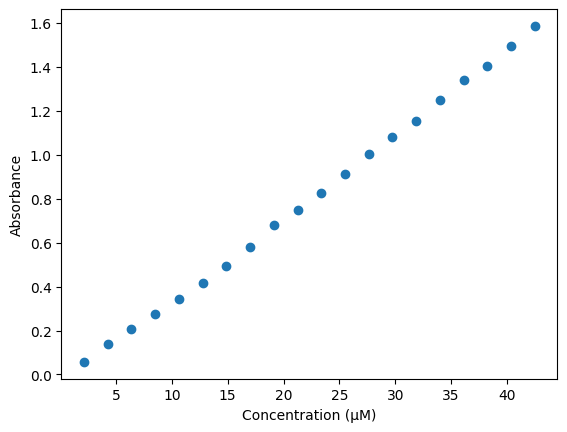

In [2]:
plt.plot(df['Concentration (µM)'], df['Absorbance'], 'o')
plt.xlabel('Concentration (µM)')
plt.ylabel('Absorbance')
plt.show()

### Fitting a linear model

Instead of solving the system of equations {ref}`eq:lsq-linear-system` manually, we can use `numpy` to compute the optimal weights directly. [`numpy.polyfit`](https://numpy.org/doc/stable/reference/generated/numpy.polyfit.html) takes features, targets, and the polynomial degree (1 for linear regression), and returns the weights that minimize squared errors.

In [3]:
# Convert columns to numpy arrays
x = df['Concentration (µM)'].values
y = df['Absorbance'].values

# Fit the model
beta = np.polyfit(x, y, 1)
print(beta)

[ 0.03800109 -0.04907034]


Plotting the fitted line together with the data is straightforward.

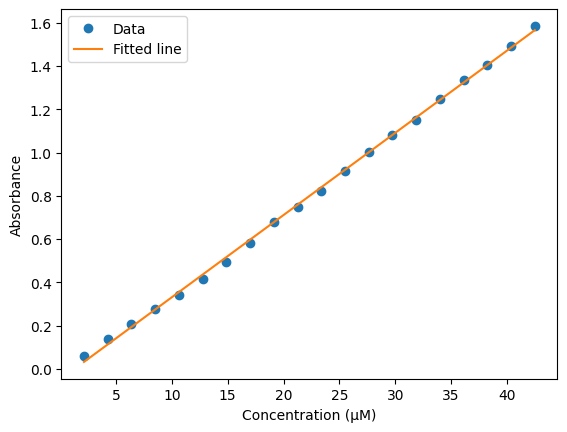

In [4]:
x_range = np.linspace(x.min(), x.max(), 1000)
plt.plot(x, y, 'o', label='Data')
plt.plot(x_range, beta[0] * x_range + beta[1], label='Fitted line')
plt.xlabel('Concentration (µM)')
plt.ylabel('Absorbance')
plt.legend()
plt.show()

:::{warning}
Note that `numpy.polyfit` returns the weights with highest degree first. Therefore, the bias is the last element of the returned array.
:::

To quantify fit quality, we compute the loss {ref}`eq:lsq-loss`, i.e. the sum of squared errors between targets and predictions.

In [5]:
print(np.sum((y - beta[0] * x - beta[1])**2))

0.0039732139069224666


### Overfitting and Cross-Validation

Because the fitted line follows the data closely, there is no immediate reason to use a more complex model. In high-dimensional or otherwise complex real-world settings, however, predictions are often not directly visualizable and we may rely on loss values alone. To illustrate how this can create a false sense of security, we now fit a higher-degree polynomial. Instead of constructing the polynomial manually, we use [`numpy.polyval`](https://numpy.org/doc/stable/reference/generated/numpy.polyval.html) to evaluate it at arbitrary points.

In [6]:
# Fit the model
degree = 15
beta = np.polyfit(x, y, degree)

# Compute the loss
loss = np.sum((y - np.polyval(beta, x))**2)
print(loss)

4.887752923343191e-05


Since the loss is much lower than before, we might conclude that the model now describes the data better. However, plotting the polynomial with the data reveals the actual reason for the low loss.

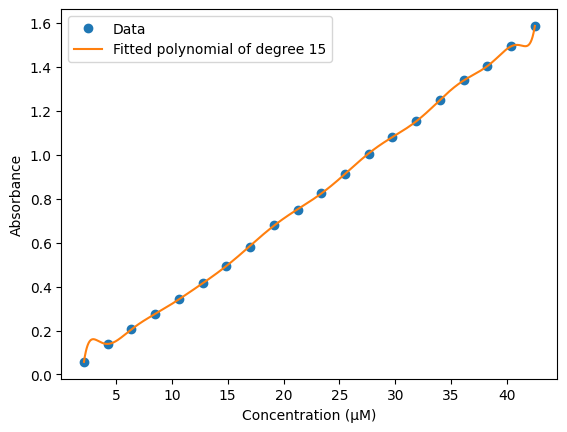

In [7]:
plt.plot(x, y, 'o', label='Data')
plt.plot(x_range, np.polyval(beta, x_range), label=f'Fitted polynomial of degree {degree}')
plt.xlabel('Concentration (µM)')
plt.ylabel('Absorbance')
plt.legend()
plt.show()

When a model fits each data point, including noise, instead of the underlying trend, the result is called **overfitting**. This usually occurs when model complexity is too high for the structure or amount of available data. Detecting and mitigating it is a central task in machine learning! A standard diagnostic is **cross-validation**: split the data into training and test sets, train on the training set, and evaluate on the test set. Here, we generate the split with [`numpy.random.choice`](https://numpy.org/doc/stable/reference/random/generated/numpy.random.choice.html), which samples elements from a given array or range.

In [8]:
# Draw random indices and set corresponding elements to True
train_mask = np.zeros(len(x), dtype=bool)
train_idx = np.random.choice(len(x), size=int(0.8 * len(x)), replace=False)
train_mask[train_idx] = True

# Split the data
x_train = x[train_mask]
y_train = y[train_mask]
x_test = x[~train_mask]
y_test = y[~train_mask]

# Fit the model
beta = np.polyfit(x_train, y_train, degree)

# Compute the loss
train_loss = np.sum((y_train - np.polyval(beta, x_train))**2)
test_loss = np.sum((y_test - np.polyval(beta, x_test))**2)
print(f'Train loss: {train_loss}')
print(f'Test loss: {test_loss}')

Train loss: 9.47022016322831e-14
Test loss: 0.367593892403425


The combination of high test loss and relatively low train loss indicates that the model has *memorized* the training data and does not generalize well to unseen data. The interactive plot below lets you explore this behavior in more detail, and the problem set discusses how regularization can be used to reduce overfitting.

In [9]:
import warnings
import altair as alt
import pandas as pd
from IPython.display import HTML, display
alt.data_transformers.disable_max_rows()

x = df['Concentration (µM)'].values
y = df['Absorbance'].values
# Keep total rows below Altair's default 5000-row limit for inline data.
x_range = np.linspace(x.min(), x.max(), 250)
DEGREE_MIN, DEGREE_MAX = 0, 20

# Reuse the same 100 splits for all slider positions.
rng = np.random.default_rng(42)
n_samples = len(x)
train_size = int(0.8 * n_samples)
splits = []
for _ in range(100):
    train_idx = rng.choice(n_samples, size=train_size, replace=False)
    test_idx = np.setdiff1d(np.arange(n_samples), train_idx)
    splits.append((train_idx, test_idx))


def compute_mean_losses(degree):
    train_losses = []
    test_losses = []
    for train_idx, test_idx in splits:
        x_train, y_train = x[train_idx], y[train_idx]
        x_test, y_test = x[test_idx], y[test_idx]
        with warnings.catch_warnings():
            warnings.simplefilter('ignore')
            beta = np.polyfit(x_train, y_train, degree)
        train_losses.append(np.sum((y_train - np.polyval(beta, x_train)) ** 2))
        test_losses.append(np.sum((y_test - np.polyval(beta, x_test)) ** 2))
    return np.mean(train_losses), np.mean(test_losses)


# Precompute curves and losses for all degrees (Jupyter Book friendly Altair slider).
prediction_records = []
loss_records = []
for degree in range(DEGREE_MIN, DEGREE_MAX + 1):
    with warnings.catch_warnings():
        warnings.simplefilter('ignore')
        beta_all = np.polyfit(x, y, degree)
    y_fit = np.polyval(beta_all, x_range)
    for xv, yv in zip(x_range, y_fit):
        prediction_records.append({'degree': degree, 'x': xv, 'y_fit': yv})

    mean_train_loss, mean_test_loss = compute_mean_losses(degree)
    mean_train_loss = max(mean_train_loss, 1e-15)
    mean_test_loss = max(mean_test_loss, 1e-15)
    loss_records.append({'degree': degree, 'split': 'Train', 'loss': mean_train_loss})
    loss_records.append({'degree': degree, 'split': 'Test', 'loss': mean_test_loss})

pred_df = pd.DataFrame(prediction_records)
loss_df = pd.DataFrame(loss_records)

global_min_loss = max(loss_df['loss'].min(), 1e-15)
global_max_loss = loss_df['loss'].max()

slider_style = """
<style>
.vega-bindings {
  width: min(360px, 100%);
  margin: 0.75rem auto 0;
}
.vega-bind {
  display: flex;
  align-items: center;
  width: 100%;
  font-size: 16px;
  line-height: 1.2;
  white-space: nowrap;
}
.vega-bind input[type="range"] {
  flex: 1 1 auto;
  min-width: 220px;
  margin-left: 0.35rem;
  margin-right: 0.75rem;
}
.vega-bind input[type="number"] {
  width: 3.25rem;
  font-size: 15px;
  line-height: 1.2;
  text-align: center;
}
</style>
"""

display(HTML(slider_style))

degree_slider = alt.param(
    name='degree',
    value=0,
    bind=alt.binding_range(min=DEGREE_MIN, max=DEGREE_MAX, step=1, name='Degree = '),
)

data_points = (
    alt.Chart(df)
    .mark_circle(size=55, color='#1f77b4')
    .encode(
        x=alt.X('Concentration (µM):Q', title='Concentration (µM)', scale=alt.Scale(domain=[x.min(), x.max()])),
        y=alt.Y('Absorbance:Q', title='Absorbance', scale=alt.Scale(domain=[0, 1.6])),
    )
)

fit_line = (
    alt.Chart(pred_df)
    .mark_line(color='#ff7f0e', strokeWidth=2.0, clip=True)
    .encode(
        x=alt.X('x:Q', title='Concentration (µM)', scale=alt.Scale(domain=[x.min(), x.max()])),
        y=alt.Y('y_fit:Q', title='Absorbance', scale=alt.Scale(domain=[0, 1.6])),
    )
    .transform_filter(alt.datum.degree == degree_slider)
)

left_chart = (data_points + fit_line).properties(width=360, height=280, title='Fit on all data')

right_chart = (
    alt.Chart(loss_df)
    .mark_bar(size=60)
    .encode(
        x=alt.X(
            'split:N',
            title=None,
            sort=['Train', 'Test']
        ),
        y=alt.Y(
            'loss:Q',
            title='Mean loss over 100 splits',
            scale=alt.Scale(
                type='log',
                domain=[
                    max(global_min_loss * 0.95, 1e-15),
                    global_max_loss * 1.05
                ]
            ),
            axis=alt.Axis(
                labelExpr="datum.value > 0 ? '10^' + format(round(log(datum.value)/log(10)), '.0f') : ''"
            ),
        ),
        y2=alt.Y2Datum(
            max(global_min_loss * 0.95, 1e-15)
        ),
        color=alt.Color(
            'split:N',
            legend=None,
            scale=alt.Scale(
                domain=['Train', 'Test'],
                range=['#1f77b4', '#ff7f0e']
            )
        ),
    )
    .transform_filter(alt.datum.degree == degree_slider)
    .properties(
        width=260,
        height=280,
        title='Train/Test loss'
    )
)

chart = alt.hconcat(left_chart, right_chart, spacing=30).add_params(degree_slider)

chart

alt.HConcatChart(...)

## Self-Study Questions

1. Derive the system of equations {eq}`eq:lsq-linear-system` by taking the derivative of the loss function with respect to the model parameters and setting it to zero.
2. Using your knowledge from the previous section on {ref}`sec:linear_systems`, identify cases where the system {eq}`eq:lsq-linear-system` is under-determined (infinite solutions).
3. Explicitly set up {eq}`eq:lsq-linear-system` for the methylene blue data, solve it using `numpy.linalg.solve` and compare the results with the analytical solution.